In [1]:
# Imports
import os, time, torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
import kagglehub
# Setup root directory
# itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
# print('Data source import complete.')
# basePath = itsahmad_indoor_scenes_cvpr_2019_path

# rootDir = basePath + "/indoorCVPR_09/Images"

In [3]:
#  Dataset Loading + Transforms
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                allData.append((os.path.join(labelDir, file), label))

trainData, tempData = train_test_split(allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42)
valData, testData = train_test_split(tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42)

labelNames = sorted(set(label for _, label in allData))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}

print(f"Train: {len(trainData)}, Val: {len(valData)}, Test: {len(testData)}")


Train: 12496, Val: 1562, Test: 1562


In [4]:
# Dataset + Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.RandomAffine(15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class SceneDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        image = self.transform(image)
        return image, labelToIndex[label]

    def __len__(self):
        return len(self.data)

trainLoader = DataLoader(SceneDataset(trainData, trainTransform), batch_size=64, shuffle=True)
valLoader = DataLoader(SceneDataset(valData, transform), batch_size=64)
testLoader = DataLoader(SceneDataset(testData, transform), batch_size=64)


In [5]:
# Teacher Model (HybridEfficientCNN_MIT67)
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        se = self.pool(x).view(b, c)
        se = self.fc(se).view(b, c, 1, 1)
        return x * se

class HybridEfficientCNN_MIT67(nn.Module):
    def __init__(self, num_classes=67):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding=2), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            SEBlock(256),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

teacher = HybridEfficientCNN_MIT67(num_classes=67).to(device)
# ,map_location=torch.device('cpu')
teacher.load_state_dict(torch.load("/kaggle/input/models/bestModel.pth"))
teacher.eval()


HybridEfficientCNN_MIT67(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool2d(kernel_size=2, stride=2, 

In [6]:
# Student Model (EfficientNet-lite)
class MiniEfficientNet(nn.Module):
    def __init__(self, num_classes=67):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.SiLU()
        )

        def MBConv(in_c, out_c, expand=6, stride=1):
            hidden = in_c * expand
            return nn.Sequential(
                nn.Conv2d(in_c, hidden, 1, bias=False), nn.BatchNorm2d(hidden), nn.SiLU(),
                nn.Conv2d(hidden, hidden, 3, stride=stride, padding=1, groups=hidden, bias=False),
                nn.BatchNorm2d(hidden), nn.SiLU(),
                SEBlock(hidden),
                nn.Conv2d(hidden, out_c, 1, bias=False), nn.BatchNorm2d(out_c)
            )

        self.blocks = nn.Sequential(
            MBConv(32, 16, expand=1),
            MBConv(16, 24, stride=2),
            MBConv(24, 40, stride=2),
            MBConv(40, 80, stride=2),
            MBConv(80, 112),
            MBConv(112, 192, stride=2),
            MBConv(192, 320)
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False), nn.BatchNorm2d(1280), nn.SiLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Flatten(),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return self.classifier(x)


In [7]:
# Distillation Training Loop
def mixup_data(x, y, alpha=0.4):
    '''Compute the mixup data. Return mixed inputs, pairs of targets, and lambda'''
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# def distillation_loss(student_logits, teacher_logits, labels, T=2.0, alpha=0.7):
#     soft_student = F.log_softmax(student_logits / T, dim=1)
#     soft_teacher = F.softmax(teacher_logits / T, dim=1)
#     soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

#     hard_loss = F.cross_entropy(student_logits, labels)
#     return alpha * soft_loss + (1 - alpha) * hard_loss

def distillation_loss(student_outputs, teacher_outputs, labels, T=2.0, alpha=0.9):
    """Combines soft distillation loss and hard label loss"""
    soft_loss = nn.KLDivLoss(reduction='batchmean')( 
        F.log_softmax(student_outputs / T, dim=1),
        F.softmax(teacher_outputs / T, dim=1)
    ) * (T * T)
    
    hard_loss = F.cross_entropy(student_outputs, labels)
    return alpha * soft_loss + (1 - alpha) * hard_loss


def evaluateModel(model, loader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            totalLoss += criterion(outputs, labels).item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return totalLoss / len(loader), correct / total


In [8]:
# Train Student
from tqdm import tqdm
import numpy as np
import time 

student = MiniEfficientNet().to(device)
optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

def trainStudent(student, teacher, trainLoader, valLoader, epochs=100, patience=10):
    bestAcc = 0
    wait = 0
    for epoch in tqdm(range(epochs)):
        student.train()
        totalLoss, correct, total = 0, 0, 0
        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            with torch.no_grad():
                teacher_logits = teacher(images)
            student_logits = student(images)
            # print("Student logits:", student_logits[0])
            # print("Teacher logits:", teacher_logits[0])
            loss = distillation_loss(student_logits, teacher_logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=5.0)
            optimizer.step()

            totalLoss += loss.item()
            _, preds = student_logits.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        valLoss, valAcc = evaluateModel(student, valLoader, nn.CrossEntropyLoss())
        scheduler.step()

        print(f"Epoch {epoch+1:02d} | Train Acc: {acc:.4f} | Val Acc: {valAcc:.4f} | Loss: {loss:.4f}")
        if valAcc > bestAcc:
            bestAcc = valAcc
            wait = 0
            torch.save(student.state_dict(), "student_best_model.pth")
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

# trainStudent(student, teacher, trainLoader, valLoader)
def train_student_with_mixup(student, teacher, train_loader, val_loader, epochs=60, T=2.0, alpha=0.9):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(student.parameters(), lr=2e-4, weight_decay=5e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    start_time = time.time()
    best_val_acc = 0
    patience = 0
    max_patience = 7

    for epoch in tqdm(range(epochs)):
        student.train()
        total_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            mixed_x, y_a, y_b, lam = mixup_data(images, labels, alpha=0.4)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_outputs = teacher(mixed_x)

            student_outputs = student(mixed_x)

            # Mixed distillation loss
            loss_a = distillation_loss(student_outputs, teacher_outputs, y_a, T, alpha)
            loss_b = distillation_loss(student_outputs, teacher_outputs, y_b, T, alpha)
            loss = lam * loss_a + (1 - lam) * loss_b

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = student_outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        val_loss, val_acc = evaluateModel(student, val_loader, criterion)
        scheduler.step()
        end_time = time.time()
        duration = start_time - end_time
        print(f"Epoch {epoch+1:02d} | Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {total_loss/len(train_loader):.4f}, Time: {duration:.2f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience = 0
            torch.save(student.state_dict(), "student_best_mixup.pth")
        else:
            patience += 1
            if patience >= max_patience:
                print("Early stopping.")
                break

# train_student_with_mixup(student, teacher, trainLoader, valLoader, epochs=100, T=2.0, alpha=0.9)



In [9]:
import matplotlib.pyplot as plt

def plot_accuracy_loss(train_acc, val_acc, train_loss, val_loss):
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy', marker='o')
    plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [10]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns
import pandas as pd

def evaluate_on_test(model, test_loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(12, 12))
    disp.plot(xticks_rotation=90, ax=ax, cmap='Blues', colorbar=False)
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    display(df_report.round(3))  # Show precision, recall, f1-score per class


In [11]:
from collections import defaultdict

def read_image_list(file_path):
    with open(file_path, 'r') as f:
        return [line.strip() for line in f.readlines()]

basePath = "/kaggle/input/indoor-scenes-cvpr-2019"
# itsahmad_indoor_scenes_cvpr_2019_path

imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
trainLabelFile = os.path.join(basePath, "TrainImages.txt")
valLabelFile = os.path.join(basePath, "TestImages.txt")
testLabelFile =  os.path.join(basePath, "TestImages.txt")

train_images = read_image_list(trainLabelFile)
val_images = read_image_list(valLabelFile)
all_images = train_images + val_images

# Count class occurrences
class_counts = defaultdict(int)
for img_path in all_images:
    class_name = img_path.split('/')[0]
    class_counts[class_name] += 1

classes = sorted(class_counts.keys())
classNames = classes
print(classes)
# evaluate_on_test(student, testLoader, classNames)


['airport_inside', 'artstudio', 'auditorium', 'bakery', 'bar', 'bathroom', 'bedroom', 'bookstore', 'bowling', 'buffet', 'casino', 'children_room', 'church_inside', 'classroom', 'cloister', 'closet', 'clothingstore', 'computerroom', 'concert_hall', 'corridor', 'deli', 'dentaloffice', 'dining_room', 'elevator', 'fastfood_restaurant', 'florist', 'gameroom', 'garage', 'greenhouse', 'grocerystore', 'gym', 'hairsalon', 'hospitalroom', 'inside_bus', 'inside_subway', 'jewelleryshop', 'kindergarden', 'kitchen', 'laboratorywet', 'laundromat', 'library', 'livingroom', 'lobby', 'locker_room', 'mall', 'meeting_room', 'movietheater', 'museum', 'nursery', 'office', 'operating_room', 'pantry', 'poolinside', 'prisoncell', 'restaurant', 'restaurant_kitchen', 'shoeshop', 'stairscase', 'studiomusic', 'subway', 'toystore', 'trainstation', 'tv_studio', 'videostore', 'waitingroom', 'warehouse', 'winecellar']


In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Compute test accuracy
    test_accuracy = accuracy_score(y_true, y_pred)
    print(f" Test Accuracy: {test_accuracy * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(12, 12))
    disp.plot(xticks_rotation=90, ax=ax, cmap='Blues', colorbar=False)
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    display(df_report.round(3))  # Includes precision, recall, f1-score per class

    return test_accuracy, df_report


In [14]:
from tqdm import tqdm
import time

def train_student_with_mixup_1(
    student, teacher, train_loader, val_loader, epochs=60, 
    T=2.0, alpha=0.9, mixup_alpha=0.4, max_patience=20
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(student.parameters(), lr=2e-4, weight_decay=5e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val_acc = 0
    patience = 0
    train_acc_list, val_acc_list, train_loss_list, val_loss_list = [], [], [], []

    for epoch in tqdm(range(epochs)):
        start_time = time.time()
        student.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            mixed_x, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_outputs = teacher(mixed_x)

            student_outputs = student(mixed_x)

            loss_a = distillation_loss(student_outputs, teacher_outputs, y_a, T, alpha)
            loss_b = distillation_loss(student_outputs, teacher_outputs, y_b, T, alpha)
            loss = lam * loss_a + (1 - lam) * loss_b

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = student_outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = total_loss / len(train_loader)
        val_loss, val_acc = evaluateModel(student, val_loader, criterion)
        scheduler.step()
        duration = time.time() - start_time

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {duration:.2f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience = 0
            torch.save(student.state_dict(), "efficientnet_student_best_mixup_2.pth")
        else:
            patience += 1
            if patience >= max_patience:
                print("Early stopping.")
                break

    return train_acc_list, val_acc_list, train_loss_list, val_loss_list


In [15]:
trainAccList, valAccList, trainLossList, valLossList = train_student_with_mixup_1(
    student, teacher, trainLoader, valLoader,
    epochs=200, T=2.0, alpha=0.9, mixup_alpha=0.4
)

  0%|          | 1/200 [06:11<20:33:13, 371.83s/it]

Epoch 01 | Train Acc: 0.0624 | Val Acc: 0.1383 | Train Loss: 1.7482 | Val Loss: 3.5781 | Time: 371.80s


  1%|          | 2/200 [09:38<15:06:55, 274.83s/it]

Epoch 02 | Train Acc: 0.0838 | Val Acc: 0.2106 | Train Loss: 1.4749 | Val Loss: 3.2745 | Time: 206.90s


  2%|▏         | 3/200 [13:04<13:18:19, 243.14s/it]

...

Epoch 151 | Train Acc: 0.2330 | Val Acc: 0.5557 | Train Loss: 0.4096 | Val Loss: 2.1380 | Time: 206.16s


 76%|███████▌  | 152/200 [8:49:40<2:44:46, 205.97s/it]

Epoch 152 | Train Acc: 0.2278 | Val Acc: 0.5499 | Train Loss: 0.4147 | Val Loss: 2.1415 | Time: 206.25s


 76%|███████▌  | 152/200 [8:53:06<2:48:21, 210.44s/it]

Epoch 153 | Train Acc: 0.2743 | Val Acc: 0.5403 | Train Loss: 0.4112 | Val Loss: 2.1453 | Time: 205.85s
Early stopping.


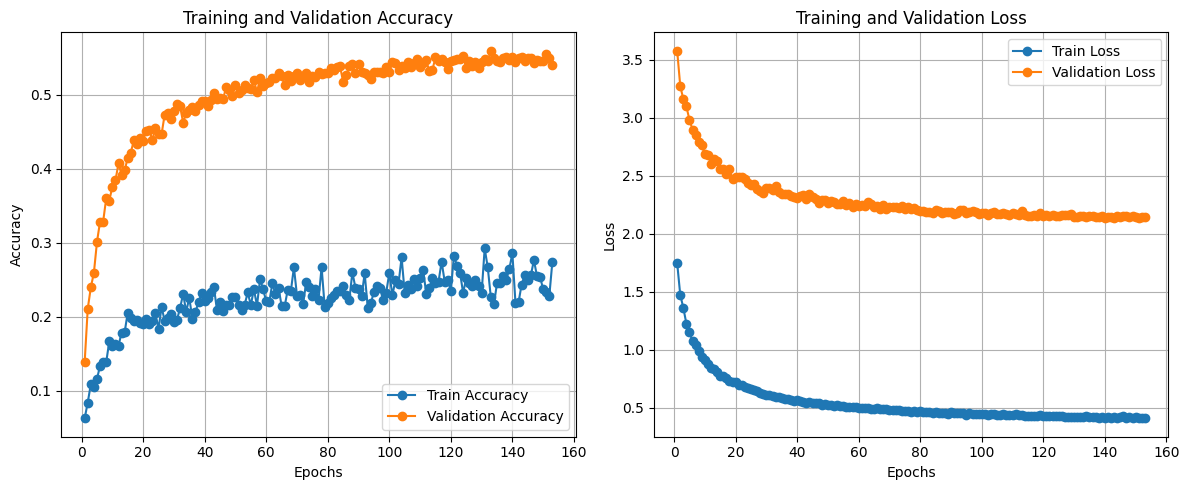

In [16]:
import matplotlib.pyplot as plt

def plot_accuracy_loss(train_acc, val_acc, train_loss, val_loss):
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy', marker='o')
    plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_accuracy_loss(trainAccList, valAccList, trainLossList, valLossList)

 Test Accuracy: 54.10%


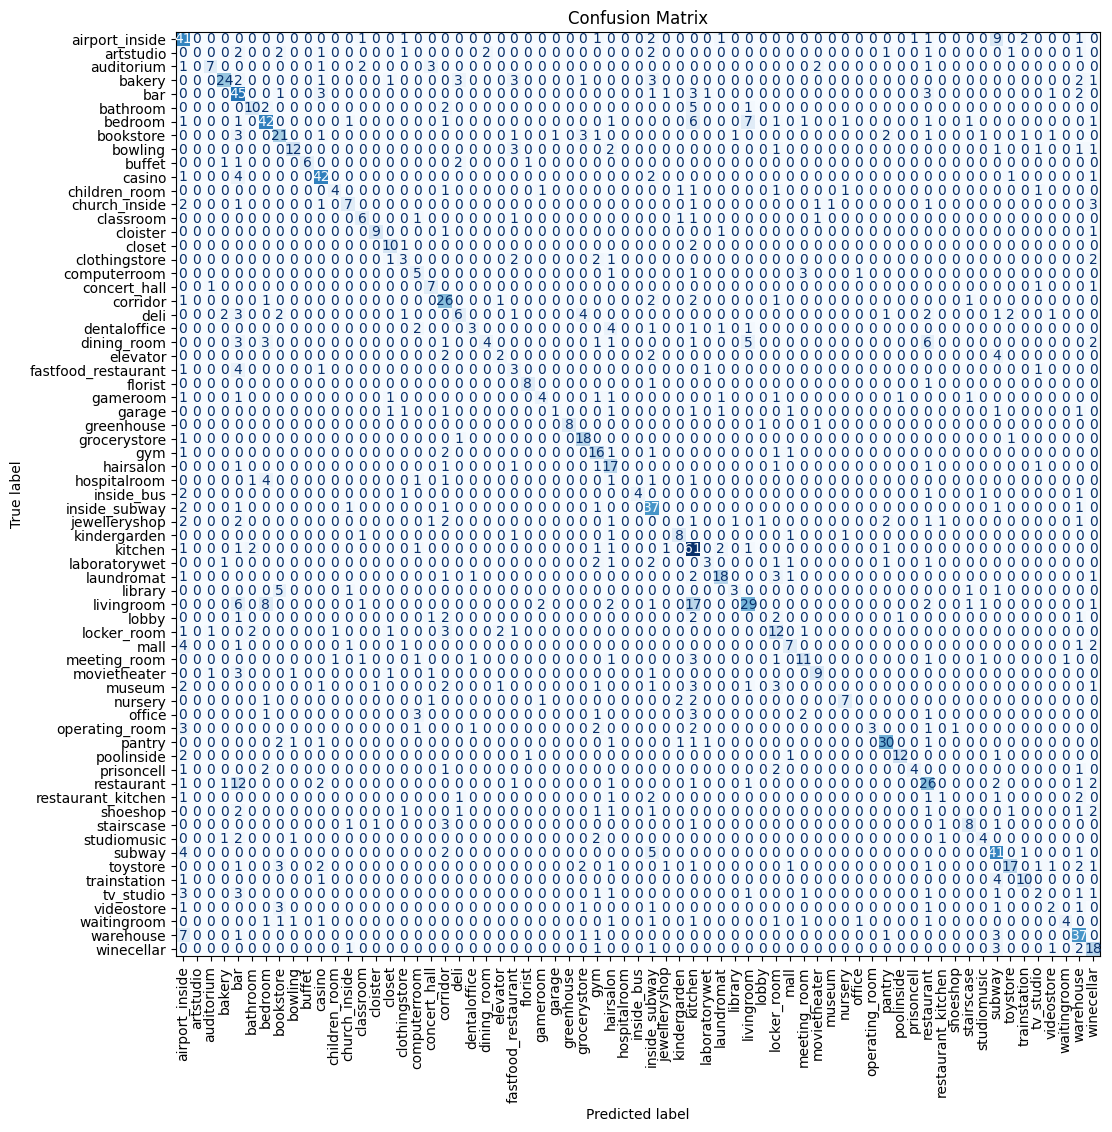

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
airport_inside,0.456,0.672,0.543,61.000
artstudio,0.000,0.000,0.000,14.000
auditorium,0.700,0.412,0.519,17.000
bakery,0.800,0.585,0.676,41.000
bar,0.421,0.738,0.536,61.000
...,...,...,...,...
warehouse,0.597,0.725,0.655,51.000
winecellar,0.429,0.667,0.522,27.000
accuracy,0.541,0.541,0.541,0.541
macro avg,0.524,0.453,0.460,1562.000


In [17]:
test_accuracy, classwise_metrics = evaluate_on_test(student, testLoader, classNames)
